Best parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}
Test Accuracy: 0.65
              precision    recall  f1-score   support

   Sensitive       0.76      0.68      0.72        98
   Resistant       0.50      0.60      0.54        52

    accuracy                           0.65       150
   macro avg       0.63      0.64      0.63       150
weighted avg       0.67      0.65      0.66       150

Feature importance plot saved as 'feature_importance.png'
Model saved: amr_model.pkl
Encoders saved: feature_encoders.pkl


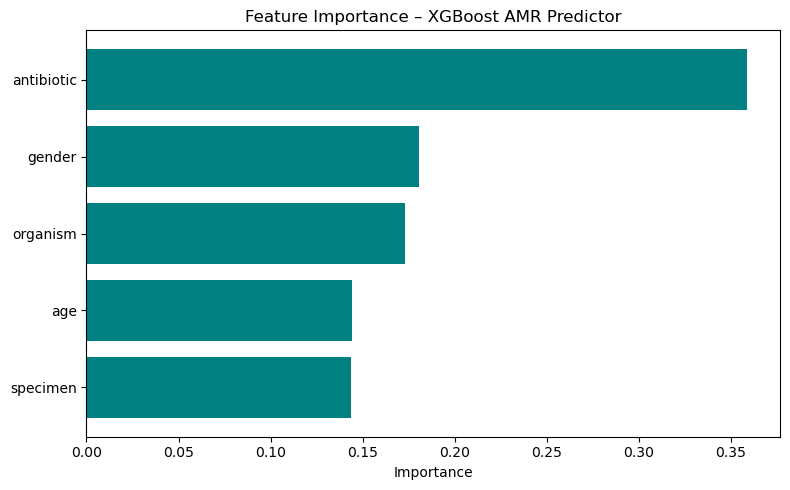

In [1]:
"""
train_model.py
Trains an XGBoost classifier on the AMR synthetic dataset,
performs hyperparameter tuning, handles class imbalance,
and saves the model and encoders for later use in the Streamlit app.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib
import xgboost as xgb
df = pd.read_csv('antibiotic_resistance_dataset.csv')
X = df.drop('resistant', axis=1)
y = df['resistant']
categorical_cols = ['gender', 'specimen', 'organism', 'antibiotic']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scale = (y_train == 0).sum() / (y_train == 1).sum()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
base_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale
)
search = RandomizedSearchCV(
    base_model,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Sensitive', 'Resistant']
))
importances = best_model.feature_importances_
features = X_train.columns
sorted_idx = importances.argsort()
plt.figure(figsize=(8, 5))
plt.barh(range(len(features)), importances[sorted_idx], color='teal')
plt.yticks(range(len(features)), features[sorted_idx])
plt.xlabel("Importance")
plt.title("Feature Importance – XGBoost AMR Predictor")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("Feature importance plot saved as 'feature_importance.png'")
joblib.dump(best_model, 'amr_model.pkl')
joblib.dump(encoders, 'feature_encoders.pkl')
print("Model saved: amr_model.pkl")
print("Encoders saved: feature_encoders.pkl")